## Gradient Boosting을 처음부터 구현하기

06에서 배깅(랜덤포레스트)을 만들었다. 여기서는 앙상블의 반대 갈래인
**부스팅(Gradient Boosting)**을 밑바닥부터 구현한다.

### 배깅 vs 부스팅
| | 배깅 (RandomForest, 06) | 부스팅 (Gradient Boosting, 08) |
|---|---|---|
| 트리 관계 | 독립·병렬 | 순차적 |
| 학습 대상 | 각자 원본 데이터 | 앞 모델의 오차(잔차) |
| 결합 | 다수결/평균 | 예측을 조금씩 누적 |
| 목적 | 분산↓ (과적합 완화) | 편향↓ (오차 보완) |

### Gradient Boosting의 핵심 아이디어
1. 일단 대충 예측 (전체 평균)
2. 오차(잔차 = 실제 − 예측) 계산
3. 새 트리가 그 오차를 예측하도록 학습
4. 예측 += learning_rate × 트리예측
5. 2~4 반복 → 오차가 점점 줄어듦

→ 각 트리는 정답이 아니라 **"앞까지 남은 오차"**를 맞힌다.

### 왜 회귀로 시작하나
회귀는 잔차가 단순한 뺄셈(실제 − 예측)이라 원리가 명확하다.
(분류는 잔차가 손실함수 미분이라 복잡 → 원리 이해 후 확장)

### 목표
- 밑바닥부터 Gradient Boosting 회귀 구현
- sklearn GradientBoostingRegressor와 비교 검증
- learning_rate·트리 개수가 성능에 미치는 영향 관찰


In [2]:
import numpy as np 

# 아주 작은 예제: y를 예측
y = np.array([10.0, 20.0, 30.0, 40.0])

# 1단계: 평균으로 예측
pred = np.full_like(y, y.mean()) 
print("초기 예측:", pred)

# 잔차 = 실제 - 예측 (얼마나 틀렸나)
residual = y - pred
print("잔차:", residual)

초기 예측: [25. 25. 25. 25.]
잔차: [-15.  -5.   5.  15.]


In [3]:
from sklearn.datasets import load_diabetes
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

# 회귀 데이터 
data = load_diabetes()
X, y = data.data, data.target

n_trees = 50
learning_rate = 0.1

pred = np.full_like(y, y.mean(), dtype=float)
trees = []


for i in range(n_trees):
    residual = y - pred
    tree = DecisionTreeRegressor(max_depth=3)
    tree.fit(X, residual)
    pred += learning_rate * tree.predict(X)
    trees.append(tree)

    if (i + 1) % 10 == 0:
        rmse = np.sqrt(mean_squared_error(y, pred))
        print(f"트리 {i+1:2d}개 | RMSE {rmse:.2f}")

트리 10개 | RMSE 54.88
트리 20개 | RMSE 48.09
트리 30개 | RMSE 44.35
트리 40개 | RMSE 41.83
트리 50개 | RMSE 40.13


잔차: [-15.  -5.   5.  15.]


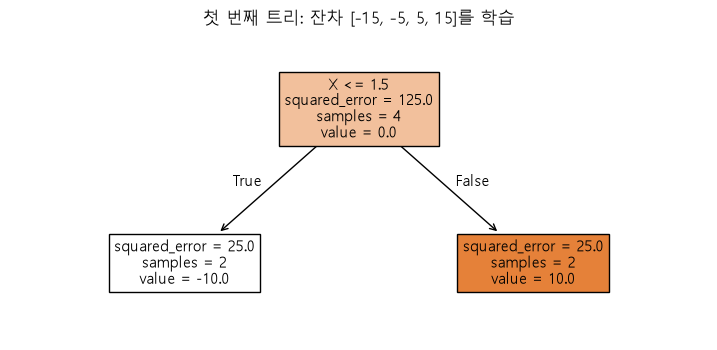

In [6]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree

# 한글 폰트 설정 (Windows 기본 폰트)
plt.rc('font', family='Malgun Gothic')

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# 토이 데이터
X_toy = np.array([[0], [1], [2], [3]])
y_toy = np.array([10.0, 20.0, 30.0, 40.0])

# 초기 예측 = 평균, 잔차 계산
pred_toy = np.full_like(y_toy, y_toy.mean())
residual_toy = y_toy - pred_toy
print("잔차:", residual_toy)

# 첫 트리: 잔차를 학습 (max_depth=1로 아주 단순하게)
tree1 = DecisionTreeRegressor(max_depth=1)
tree1.fit(X_toy, residual_toy)

# 트리 그리기
plt.figure(figsize=(9, 4))
plot_tree(tree1, filled=True, feature_names=["X"], fontsize=11)
plt.title("첫 번째 트리: 잔차 [-15, -5, 5, 15]를 학습")
plt.show()